In [1]:

from google.colab import files
import os
import zipfile

# Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()   # a file picker will appear


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [2]:

# Place it where Kaggle CLI expects it
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)   # required permissions


In [3]:


# Install Kaggle CLI and download the dataset
os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

0

In [4]:
# Unzip
zip_path = "database-for-emotion-recognition-system-gameemo.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")

print("\nDone! Dataset extracted.")
print("Folders found:", [f for f in os.listdir(".") if os.path.isdir(f)])


Done! Dataset extracted.
Folders found: ['.config', 'GAMEEMO', 'sample_data']


In [5]:

!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cur

In [1]:
import numpy as np
import pandas as pd
import os, glob, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import Scaler as DiagramScaler


In [2]:
# ── CELL 4: Config ────────────────────────────────────────────────
DATA_DIR = "./GAMEEMO"

CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

EMOTIONS = {"G1": "Boring", "G2": "Calm", "G3": "Horror", "G4": "Funny"}
EMOTION_LABELS = list(EMOTIONS.values())

# Per-channel embedding params — each channel finds its own optimal
# time_delay/dimension via "search", but search runs SEPARATELY on
# the train / val / test signal (each only sees its own data)
TIME_DELAY = 2   # starting guess for search
DIMENSION  = 3   # starting guess for search

SW_SIZE       = 20
SW_STRIDE     = 10
HOMOLOGY_DIMS = (0, 1)

# Feature budget per channel: 3 lifetime stats (mean/std/max) x 2 homology
# dims + 2 persistence-entropy values (H0, H1) = 8. Betti curve dropped.
FEAT_PER_CHANNEL = 8
N_CHANNELS       = len(CHANNELS)

# FIX: train/val/test are now carved out of the RAW signal (contiguous,
# time-ordered) *before* Takens embedding + sliding-window ever runs.
# Previously val was a random split of already-windowed, 50%-overlapping
# vectors (SW_STRIDE=10 with SW_SIZE=20) — neighbouring windows share
# 10/20 raw points, so random splitting put near-duplicate windows on
# both sides of the split and inflated val_acc. Test didn't have this
# problem (it came from a genuinely separate raw segment), which is why
# test_acc was so much lower than val_acc — val was leaking, test wasn't.
TRAIN_FRAC = 0.65
VAL_FRAC   = 0.15
TEST_FRAC  = 0.20   # = 1 - TRAIN_FRAC - VAL_FRAC

RANDOM_STATE = 42


In [3]:
#CELL 5: Load one subject's data ───────────────────────────────
def load_subject(subject_id):
    all_X, all_y = [], []

    csv_dir = os.path.join(
        DATA_DIR,
        f"(S{subject_id:02d})",
        "Preprocessed EEG Data",
        ".csv format"
    )

    for game_tag in EMOTIONS:
        label = list(EMOTIONS.keys()).index(game_tag)
        fname = f"S{subject_id:02d}{game_tag}AllChannels.csv"
        fpath = os.path.join(csv_dir, fname)

        if not os.path.exists(fpath):
            print(f"  [warn] not found: {fname}")
            continue

        df   = pd.read_csv(fpath)
        cols = [c for c in df.columns if c in CHANNELS]
        if not cols:
            cols = df.select_dtypes(include=np.number).columns[:14].tolist()

        data = df[cols].values.astype(np.float64) #here data is storing values like just of our dataset total n timestamps in rows and 14 colums, that way only in  numpy ,represmtation different yet all same

        all_X.append(data)                                    # keep as separate block
        all_y.append(np.full(len(data), label, dtype=int))

    if not all_X:
        raise FileNotFoundError(f"No CSVs found for S{subject_id:02d}")

    # Return list of (X_block, y_block) per emotion — NOT concatenated.
    # Concatenating here and splitting 80/20 afterwards would put the
    # entire test set inside the last emotion block (G4/Funny) only.
    return all_X, all_y




In [4]:
# ── CELL 6: Lifetime stats (mean / std / max persistence) ─────────
def persistence_stats(X_pd):
    """
    Compact per-window topological summary. For each homology dimension,
    computes the mean, std, and max of the persistence *lifetimes*
    (death - birth) instead of raw birth/death values.

    Lifetime is the most informative single quantity in a persistence
    diagram: short-lived points are almost always noise, long-lived
    points are the real topological signal. max(lifetime) in particular
    is the "most persistent feature" — a strong, well-known discriminative
    stat in TDA-on-biosignal literature — so it's included alongside the
    mean/std summary.

    Returns (n_windows, 3 * len(HOMOLOGY_DIMS))  ->  (n_windows, 6) here.
    """
    n_windows = X_pd.shape[0]
    all_rows  = []
    for w in range(n_windows):
        row = []
        for dim in HOMOLOGY_DIMS:
            pts    = X_pd[w][X_pd[w, :, 2] == dim]
            finite = pts[np.isfinite(pts[:, 1])]
            if len(finite) == 0:
                row.extend([0.0, 0.0, 0.0])
            else:
                l = finite[:, 1] - finite[:, 0]
                row.extend([l.mean(), l.std(), l.max()])
        all_rows.append(row)
    return np.array(all_rows)
#total n windows. each window- 6 features (3 stats x 2 homology dims).


it is using persisetent homology computed later on. to find out the stats/

In [5]:
# ── CELL 7: TDA features for one channel split ───────────────────
def tda_on_signal(signal, labels):
    """
    Run TDA pipeline on a 1-D signal. Each call independently searches
    for the optimal time_delay/dimension for THIS signal only — so when
    called separately on train and test, there's no leakage between them.

    signal : (T,)
    labels : (T,)

    Returns
    -------
    X_feat : (n_windows, 8)   -- 6 lifetime stats + 2 persistence-entropy
    y_win  : (n_windows,)
    """
    # Step 1 — SingleTakensEmbedding, per-channel optimal params via search.
    # "search" looks ONLY at the signal passed in here — when called on the
    # train split it never sees test data, and vice versa.
    STE = SingleTakensEmbedding(
        parameters_type="search",
        time_delay=TIME_DELAY,
        dimension=DIMENSION,
        n_jobs=-1,#use all cpus.
    )
    X_emb, y_emb = STE.fit_transform_resample(signal, labels)

    # Step 2 — SlidingWindow over embedded point cloud
    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(X_emb, y_emb)#x_win.shape has(no of windows,window_size,embedding_dimension)

    # Step 3 — VietorisRipsPersistence
    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = VR.fit_transform(X_win)
    X_pd = DiagramScaler().fit_transform(X_pd)#
#The persistence diagrams are scaled/normalized.

#This makes the numerical ranges more comparable across different windows before feature extraction. It helps ensure that later features are not dominated simply because one diagram has larger birth/death values than another.

#Notice that the topology (which features exist) does not change—the coordinates are just rescaled.
#

    # Step 4 — Compact feature set: lifetime stats + persistence entropy.
    # Betti curve, amplitude, and number-of-points dropped — they were
    # largely redundant with lifetime/entropy here and just inflated the
    # feature count without adding much discriminative signal.
    feat_life = persistence_stats(X_pd)  # cell-6, (n_win, 6)
    feat_pe   = PersistenceEntropy(normalize=True, nan_fill_value=0.0).fit_transform(X_pd)  # (n_win, 2)

    X_feat = np.hstack([feat_life, feat_pe])   # (n_win, 8)
    return X_feat, y_win


In [6]:
# ── CELL 8: Extract features from one subject ─────────────────────
def extract_subject_features(subject_id):
    """
    Load subject data as separate emotion blocks. For EACH emotion block,
    carve out TRAIN / VAL / TEST as three CONTIGUOUS, non-overlapping
    time segments (train first, then val, then test) so no sliding
    window ever straddles a split boundary. TDA is run independently on
    each segment.

    FIX (accuracy): after building features, apply PER-SUBJECT z-score
    normalization using only this subject's own train stats (mu/sigma),
    then apply that same transform to this subject's val/test. This
    removes subject-to-subject scale/offset differences in the raw TDA
    feature values BEFORE pooling across subjects — without this, the
    downstream global StandardScaler just standardizes a mixture of
    differently-shifted distributions, which wastes model capacity and
    hurts cross-subject accuracy. No leakage: each subject's own train
    segment supplies its own mu/sigma.
    """
    blocks_X, blocks_y = load_subject(subject_id)

    tr_blocks_X, tr_blocks_y   = [], []
    val_blocks_X, val_blocks_y = [], []
    te_blocks_X, te_blocks_y   = [], []

    for X_block, y_block in zip(blocks_X, blocks_y):
        n = len(y_block)
        tr_end  = int(n * TRAIN_FRAC)
        val_end = int(n * (TRAIN_FRAC + VAL_FRAC))
        tr_blocks_X.append(X_block[:tr_end]);         tr_blocks_y.append(y_block[:tr_end])
        val_blocks_X.append(X_block[tr_end:val_end]); val_blocks_y.append(y_block[tr_end:val_end])
        te_blocks_X.append(X_block[val_end:]);        te_blocks_y.append(y_block[val_end:])

    X_tr_all, X_val_all, X_te_all = [], [], []
    y_tr_all, y_val_all, y_te_all = None, None, None
    min_tr, min_val, min_te       = None, None, None

    n_channels = blocks_X[0].shape[1]

    for ch_idx in range(n_channels):
        ch = CHANNELS[ch_idx]
        print(f"  S{subject_id:02d} [{ch_idx+1:02d}/14] {ch} ...", end=" ", flush=True)
        try:
            feat_tr_parts, y_tr_parts   = [], []
            feat_val_parts, y_val_parts = [], []
            feat_te_parts, y_te_parts   = [], []

            for X_tr_b, y_tr_b, X_val_b, y_val_b, X_te_b, y_te_b in zip(
                tr_blocks_X, tr_blocks_y, val_blocks_X, val_blocks_y, te_blocks_X, te_blocks_y
            ):
                f_tr,  yw_tr  = tda_on_signal(X_tr_b[:, ch_idx],  y_tr_b)
                f_val, yw_val = tda_on_signal(X_val_b[:, ch_idx], y_val_b)
                f_te,  yw_te  = tda_on_signal(X_te_b[:, ch_idx],  y_te_b)
                feat_tr_parts.append(f_tr);   y_tr_parts.append(yw_tr)
                feat_val_parts.append(f_val); y_val_parts.append(yw_val)
                feat_te_parts.append(f_te);   y_te_parts.append(yw_te)

            feat_tr  = np.vstack(feat_tr_parts);  y_tr_win  = np.concatenate(y_tr_parts)
            feat_val = np.vstack(feat_val_parts); y_val_win = np.concatenate(y_val_parts)
            feat_te  = np.vstack(feat_te_parts);  y_te_win  = np.concatenate(y_te_parts)

            X_tr_all.append(feat_tr)
            X_val_all.append(feat_val)
            X_te_all.append(feat_te)

            if y_tr_all is None:
                y_tr_all, y_val_all, y_te_all = y_tr_win, y_val_win, y_te_win
                min_tr, min_val, min_te = feat_tr.shape[0], feat_val.shape[0], feat_te.shape[0]
            else:
                min_tr  = min(min_tr, feat_tr.shape[0])
                min_val = min(min_val, feat_val.shape[0])
                min_te  = min(min_te, feat_te.shape[0])

            print(f"tr_wins={feat_tr.shape[0]}, val_wins={feat_val.shape[0]}, te_wins={feat_te.shape[0]}")
        except Exception as e:
            print(f"SKIPPED — {e}")

    if not X_tr_all:
        return None, None, None, None, None, None

    X_tr  = np.hstack([f[:min_tr]  for f in X_tr_all])
    X_val = np.hstack([f[:min_val] for f in X_val_all])
    X_te  = np.hstack([f[:min_te]  for f in X_te_all])
    y_tr  = y_tr_all[:min_tr]
    y_val = y_val_all[:min_val]
    y_te  = y_te_all[:min_te]

    X_tr  = np.nan_to_num(X_tr,  nan=0.0, posinf=0.0, neginf=0.0)
    X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
    X_te  = np.nan_to_num(X_te,  nan=0.0, posinf=0.0, neginf=0.0)

    # ── PER-SUBJECT NORMALIZATION ──────────────────────────────────
    # mu/sigma computed from THIS subject's train segment only, then
    # applied to this subject's val/test too. Removes inter-subject
    # scale/baseline differences before we pool everyone together.
    subj_mu = X_tr.mean(axis=0, keepdims=True)
    subj_sd = X_tr.std(axis=0, keepdims=True)
    subj_sd[subj_sd < 1e-8] = 1.0
    X_tr  = (X_tr  - subj_mu) / subj_sd
    X_val = (X_val - subj_mu) / subj_sd
    X_te  = (X_te  - subj_mu) / subj_sd

    return X_tr, y_tr, X_val, y_val, X_te, y_te


first in cell 8 there was vstack of same channel diff block, then different channerls were hstacked.

In [7]:

# ── CELL 9: Confusion matrix plot ─────────────────────────────────
def plot_cm(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTION_LABELS,
                yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


until now we learned how to process: one subject and extracted its features-training and testing...now we will be doing for all subjects

In [8]:
# ── CELL 10: Collect features from all subjects ───────────────────
print("Extracting TDA features from all subjects...")

all_X_tr, all_y_tr   = [], []
all_X_val, all_y_val = [], []
all_X_te, all_y_te   = [], []

for sid in range(1, 5):   # bump this up to more subjects once the pipeline checks out
    print(f"\n{'='*50}")
    print(f"Subject S{sid:02d}")
    print(f"{'='*50}")
    try:
        X_tr, y_tr, X_val, y_val, X_te, y_te = extract_subject_features(sid)
        if X_tr is not None:
            all_X_tr.append(X_tr);   all_y_tr.append(y_tr)
            all_X_val.append(X_val); all_y_val.append(y_val)
            all_X_te.append(X_te);   all_y_te.append(y_te)
    except FileNotFoundError as e:
        print(f"  [skip] {e}")
    except Exception as e:
        print(f"  [error] {e}")

# Pool all subjects together
X_train  = np.vstack(all_X_tr);  y_train  = np.concatenate(all_y_tr)
X_valset = np.vstack(all_X_val); y_valset = np.concatenate(all_y_val)
X_test   = np.vstack(all_X_te);  y_test   = np.concatenate(all_y_te)

print(f"\nTrain : {X_train.shape}  |  Val : {X_valset.shape}  |  Test : {X_test.shape}")


Extracting TDA features from all subjects...

Subject S01
  S01 [01/14] AF3 ... tr_wins=9939, val_wins=2288, te_wins=3052
  S01 [02/14] F7 ... tr_wins=9938, val_wins=2288, te_wins=3052
  S01 [03/14] F3 ... tr_wins=9939, val_wins=2288, te_wins=3052
  S01 [04/14] FC5 ... tr_wins=9940, val_wins=2288, te_wins=3052
  S01 [05/14] T7 ... tr_wins=9940, val_wins=2288, te_wins=3052
  S01 [06/14] P7 ... tr_wins=9938, val_wins=2288, te_wins=3052
  S01 [07/14] O1 ... tr_wins=9938, val_wins=2288, te_wins=3052
  S01 [08/14] O2 ... tr_wins=9940, val_wins=2288, te_wins=3052
  S01 [09/14] P8 ... tr_wins=9937, val_wins=2288, te_wins=3052
  S01 [10/14] T8 ... tr_wins=9940, val_wins=2288, te_wins=3052
  S01 [11/14] FC6 ... tr_wins=9940, val_wins=2288, te_wins=3052
  S01 [12/14] F4 ... tr_wins=9940, val_wins=2288, te_wins=3052
  S01 [13/14] F8 ... tr_wins=9939, val_wins=2288, te_wins=3052
  S01 [14/14] AF4 ... tr_wins=9939, val_wins=2288, te_wins=3052

Subject S02
  S02 [01/14] AF3 ... tr_wins=9940, val_win

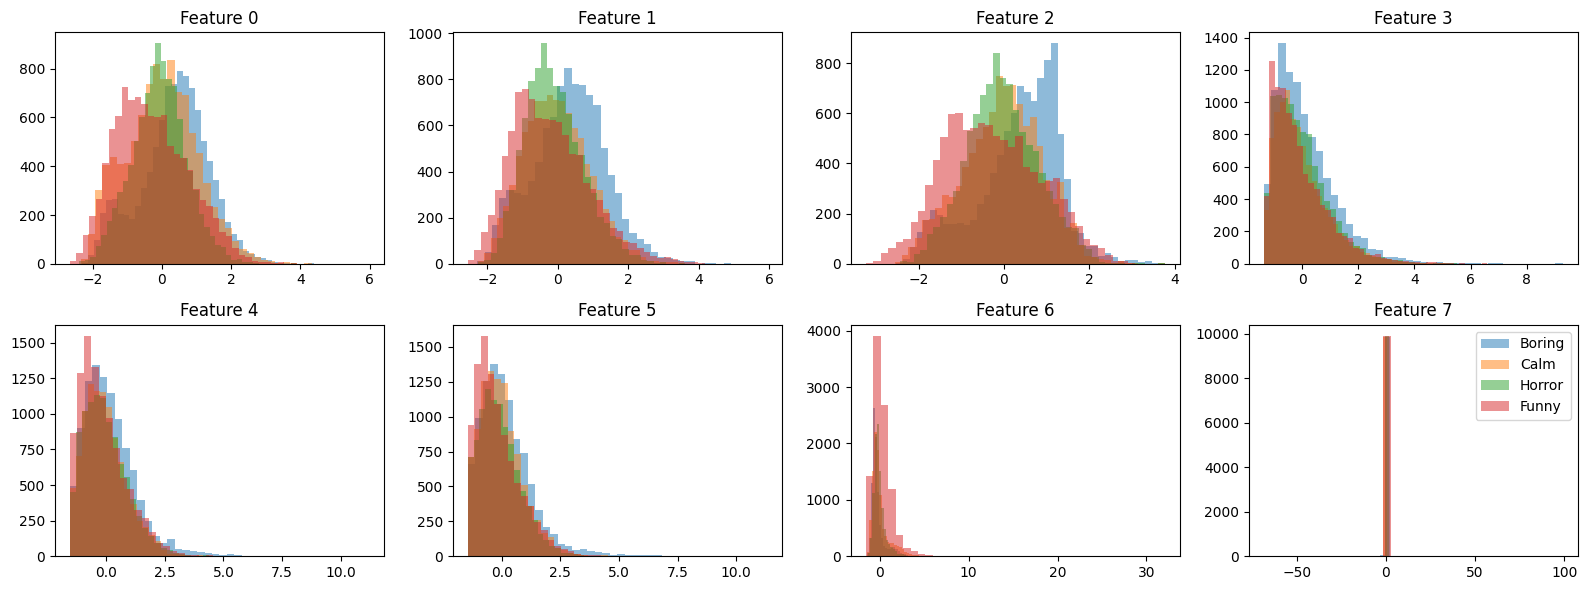

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    for cls in range(4):
        vals = X_train[y_train == cls, i]
        ax.hist(vals, bins=40, alpha=0.5, label=EMOTION_LABELS[cls])
    ax.set_title(f"Feature {i}")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
 #── CELL 11: Scale + reshape for 1D-CNN ────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_valset)
X_test_sc  = scaler.transform(X_test)

assert X_train_sc.shape[1] == N_CHANNELS * FEAT_PER_CHANNEL, \
    f"expected {N_CHANNELS*FEAT_PER_CHANNEL} cols, got {X_train_sc.shape[1]}"

# Reshape (n_windows, 14*8) -> (n_windows, 14, 8) -> (n_windows, 8, 14).
def to_cnn_input(X_flat):
    X_r = X_flat.reshape(-1, N_CHANNELS, FEAT_PER_CHANNEL)
    return np.transpose(X_r, (0, 2, 1))   # (n, FEAT_PER_CHANNEL, N_CHANNELS)

X_train_cnn = to_cnn_input(X_train_sc)
X_val_cnn   = to_cnn_input(X_val_sc)
X_test_cnn  = to_cnn_input(X_test_sc)
print(f"CNN input shape: {X_train_cnn.shape}  (batch, feat_per_channel, n_eeg_channels)")

# FIX: val is no longer carved out here with a random train_test_split
# over already-windowed (overlapping) vectors. It's now the genuinely
# independent segment built in CELL 8/10 (X_valset/y_valset), extracted
# with its own separate TDA pass just like test. That's what closes the
# val/test accuracy gap you were seeing.
X_tr_t      = torch.tensor(X_train_cnn, dtype=torch.float32)
y_tr_t      = torch.tensor(y_train,     dtype=torch.long)
X_val_t     = torch.tensor(X_val_cnn,   dtype=torch.float32)
y_val_split = y_valset
X_te_t      = torch.tensor(X_test_cnn,  dtype=torch.float32)
y_te_t      = torch.tensor(y_test,      dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=512, shuffle=True)
print(f"train={X_tr_t.shape[0]}  val={X_val_t.shape[0]}  test={X_te_t.shape[0]}")


CNN input shape: (39747, 8, 14)  (batch, feat_per_channel, n_eeg_channels)
train=39747  val=9152  test=12208


In [11]:
# ── 1D-CNN definition ────────────────────────────────────────────
# v3: added a 3rd conv block wired as a residual (skip) connection on
# top of the SE-attention + avg/max-pool design. More representational
# capacity than the 2-block version without the vanishing-gradient risk
# of just stacking layers naively.
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        hidden = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1)
        return x * w


class ResBlock(nn.Module):
    def __init__(self, channels, dropout=0.25):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.conv(x))


class TDA_CNN1D(nn.Module):
    def __init__(self, feat_per_channel, n_channels, n_classes=4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(feat_per_channel, 48, kernel_size=3, padding=1),
            nn.BatchNorm1d(48),
            nn.GELU(),
            nn.Dropout(0.25),
        )
        self.se1 = SEBlock(48)

        self.conv2 = nn.Sequential(
            nn.Conv1d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.Dropout(0.3),
        )
        self.se2 = SEBlock(96)

        self.res_block = ResBlock(96, dropout=0.25)
        self.se3 = SEBlock(96)

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(96 * 2, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (batch, feat_per_channel, n_channels)
        x = self.stem(x)
        x = self.se1(x)
        x = self.conv2(x)
        x = self.se2(x)
        x = self.res_block(x)
        x = self.se3(x)
        avg = self.avg_pool(x).flatten(1)
        mx  = self.max_pool(x).flatten(1)
        x   = torch.cat([avg, mx], dim=1)
        return self.fc(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [12]:
# ── Quick hyperparameter search (short runs) ───────────────────────
# Random search over the knobs that were previously just reasonable
# guesses (mixup alpha, channel-dropout rate, weight decay, max_lr).
# Each config trains for a SHORT budget (15 epochs) just to rank
# configs relative to each other — then the winner gets a full run
# in the next cell. Picked on VAL only.
import itertools
import random as pyrandom

def make_model():
    return TDA_CNN1D(feat_per_channel=FEAT_PER_CHANNEL, n_channels=N_CHANNELS).to(device)

def quick_train_eval(mixup_alpha, chan_drop_p, weight_decay, max_lr, short_epochs=15):
    m = make_model()
    crit = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt = torch.optim.AdamW(m.parameters(), lr=max_lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=max_lr, epochs=short_epochs, steps_per_epoch=len(train_loader),
        pct_start=0.3, div_factor=10, final_div_factor=50,
    )
    for ep in range(short_epochs):
        m.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            Xb = Xb + torch.randn_like(Xb) * 0.05
            if chan_drop_p > 0:
                mask = (torch.rand(Xb.size(0), 1, Xb.size(2), device=device) > chan_drop_p).float()
                Xb = Xb * mask
            if mixup_alpha > 0:
                lam = float(np.random.beta(mixup_alpha, mixup_alpha))
                idx = torch.randperm(Xb.size(0), device=device)
                Xm = lam * Xb + (1 - lam) * Xb[idx]
                ya, yb2 = yb, yb[idx]
            else:
                Xm, ya, yb2, lam = Xb, yb, yb, 1.0
            opt.zero_grad()
            out = m(Xm)
            loss = lam * crit(out, ya) + (1 - lam) * crit(out, yb2)
            loss.backward()
            opt.step()
            sched.step()
    m.eval()
    with torch.no_grad():
        val_pred = m(X_val_t.to(device)).argmax(1).cpu().numpy()
    return accuracy_score(y_val_split, val_pred)

search_space = {
    "mixup_alpha":  [0.0, 0.2, 0.3, 0.4],
    "chan_drop_p":  [0.0, 0.1, 0.15, 0.25],
    "weight_decay": [1e-3, 1e-2, 3e-2],
    "max_lr":       [5e-4, 8e-4, 1e-3, 1.5e-3],
}

N_TRIALS = 12
pyrandom.seed(RANDOM_STATE)
trials = []
for _ in range(N_TRIALS):
    cfg = {k: pyrandom.choice(v) for k, v in search_space.items()}
    trials.append(cfg)

print(f"Running {N_TRIALS} short (15-epoch) trials to rank hyperparameter configs...\n")
results = []
for i, cfg in enumerate(trials, 1):
    acc = quick_train_eval(cfg["mixup_alpha"], cfg["chan_drop_p"], cfg["weight_decay"], cfg["max_lr"])
    results.append((acc, cfg))
    print(f"  Trial {i:02d}/{N_TRIALS}: {cfg} -> val_acc={acc:.4f}")

results.sort(key=lambda x: -x[0])
best_acc, best_cfg = results[0]
print(f"\nBest short-run config: {best_cfg} -> val_acc={best_acc:.4f}")
print("(This picks a promising region, not a final number — the full run below trains much longer.)")


Running 12 short (15-epoch) trials to rank hyperparameter configs...

  Trial 01/12: {'mixup_alpha': 0.0, 'chan_drop_p': 0.0, 'weight_decay': 0.03, 'max_lr': 0.001} -> val_acc=0.4352
  Trial 02/12: {'mixup_alpha': 0.2, 'chan_drop_p': 0.1, 'weight_decay': 0.001, 'max_lr': 0.0005} -> val_acc=0.3824
  Trial 03/12: {'mixup_alpha': 0.0, 'chan_drop_p': 0.25, 'weight_decay': 0.001, 'max_lr': 0.0005} -> val_acc=0.3623
  Trial 04/12: {'mixup_alpha': 0.0, 'chan_drop_p': 0.1, 'weight_decay': 0.001, 'max_lr': 0.0005} -> val_acc=0.3919
  Trial 05/12: {'mixup_alpha': 0.2, 'chan_drop_p': 0.25, 'weight_decay': 0.001, 'max_lr': 0.0015} -> val_acc=0.4199
  Trial 06/12: {'mixup_alpha': 0.3, 'chan_drop_p': 0.0, 'weight_decay': 0.001, 'max_lr': 0.0015} -> val_acc=0.4485
  Trial 07/12: {'mixup_alpha': 0.3, 'chan_drop_p': 0.15, 'weight_decay': 0.001, 'max_lr': 0.0008} -> val_acc=0.3905
  Trial 08/12: {'mixup_alpha': 0.3, 'chan_drop_p': 0.0, 'weight_decay': 0.001, 'max_lr': 0.0015} -> val_acc=0.4403
  Trial 0

In [13]:
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

# ── Focal loss ──────────────────────────────────────────────────────
# Down-weights examples the model already classifies confidently and
# correctly, so gradient signal concentrates on the hard/ambiguous
# windows -- the ones actually holding accuracy back. gamma=2 is the
# standard default from the original focal-loss paper.
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing, reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()


model     = TDA_CNN1D(feat_per_channel=FEAT_PER_CHANNEL, n_channels=N_CHANNELS).to(device)
criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)

EPOCHS = 100   # fixed budget — OneCycleLR needs to know this upfront

# Use the winning config from the hyperparameter search above, BUT don't
# trust it blindly: the search only trains each candidate for 15 epochs
# as a cheap proxy, and regularization (mixup, channel-dropout) trades
# away early-epoch fit for long-run generalization -- a 15-epoch window
# can't see that payoff, so the search tends to favor "no regularization"
# configs that overfit hard once trained for the full 100 epochs (this is
# exactly what happened: train_acc hit 0.96, test_acc dropped to 0.48).
# Fix: enforce a regularization floor regardless of what the search picked.
_cfg = dict(best_cfg) if "best_cfg" in dir() else {
    "mixup_alpha": 0.3, "chan_drop_p": 0.15, "weight_decay": 1e-2, "max_lr": 1e-3,
}
MIN_MIXUP_ALPHA = 0.2
MIN_CHAN_DROP_P = 0.1
if _cfg["mixup_alpha"] < MIN_MIXUP_ALPHA:
    print(f"[override] search picked mixup_alpha={_cfg['mixup_alpha']}, too low -> using {MIN_MIXUP_ALPHA}")
    _cfg["mixup_alpha"] = MIN_MIXUP_ALPHA
if _cfg["chan_drop_p"] < MIN_CHAN_DROP_P:
    print(f"[override] search picked chan_drop_p={_cfg['chan_drop_p']}, too low -> using {MIN_CHAN_DROP_P}")
    _cfg["chan_drop_p"] = MIN_CHAN_DROP_P
MIXUP_ALPHA    = _cfg["mixup_alpha"]
CHANNEL_DROP_P = _cfg["chan_drop_p"]
print(f"Using config: {_cfg}")

optimizer = torch.optim.AdamW(model.parameters(), lr=_cfg["max_lr"], weight_decay=_cfg["weight_decay"])
steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=_cfg["max_lr"], epochs=EPOCHS, steps_per_epoch=steps_per_epoch,
    pct_start=0.25, div_factor=10, final_div_factor=100,
)

NOISE_STD = 0.05

SWA_START     = int(EPOCHS * 0.7)
swa_model     = AveragedModel(model)
swa_scheduler = SWALR(optimizer, swa_lr=2e-4)

best_val_acc, best_weights = 0.0, None


def mixup(x, y, alpha):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    x2  = lam * x + (1 - lam) * x[idx]
    return x2, y, y[idx], lam


def channel_dropout(x, p):
    if p <= 0:
        return x
    mask = (torch.rand(x.size(0), 1, x.size(2), device=x.device) > p).float()
    return x * mask


print(f"\nTraining 1D-CNN — OneCycleLR + FocalLoss, {EPOCHS} epochs, SWA from epoch {SWA_START}...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch + torch.randn_like(X_batch) * NOISE_STD
        X_batch = channel_dropout(X_batch, CHANNEL_DROP_P)
        X_mix, y_a, y_b, lam = mixup(X_batch, y_batch, MIXUP_ALPHA)

        optimizer.zero_grad()
        out  = model(X_mix)
        loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
        loss.backward()
        optimizer.step()
        if epoch <= SWA_START:
            scheduler.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()  # approx under mixup
        total      += len(y_batch)

    if epoch > SWA_START:
        swa_model.update_parameters(model)
        swa_scheduler.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t.to(device)).argmax(1).cpu().numpy()
    val_acc   = accuracy_score(y_val_split, val_pred)
    train_acc = correct / total

    if epoch % 5 == 0 or epoch == EPOCHS:
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:03d} — loss={total_loss/total:.4f}, train_acc~={train_acc:.4f}, val_acc={val_acc:.4f}, lr={cur_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    model.train()

update_bn(train_loader, swa_model, device=device)
swa_model.eval()
with torch.no_grad():
    swa_val_pred = swa_model(X_val_t.to(device)).argmax(1).cpu().numpy()
swa_val_acc = accuracy_score(y_val_split, swa_val_pred)

print(f"\nBest single-checkpoint val_acc: {best_val_acc:.4f}")
print(f"SWA-averaged val_acc:          {swa_val_acc:.4f}")

if swa_val_acc >= best_val_acc:
    best_weights = swa_model.module.state_dict()
    best_val_acc = swa_val_acc
    print("Using SWA weights (better).")
else:
    print("Using best single-checkpoint weights (better).")


[override] search picked chan_drop_p=0.0, too low -> using 0.1
Using config: {'mixup_alpha': 0.3, 'chan_drop_p': 0.1, 'weight_decay': 0.001, 'max_lr': 0.0015}

Training 1D-CNN — OneCycleLR + FocalLoss, 100 epochs, SWA from epoch 70...
  Epoch 005 — loss=0.6830, train_acc~=0.3708, val_acc=0.3082, lr=2.79e-04
  Epoch 010 — loss=0.6089, train_acc~=0.4114, val_acc=0.3208, lr=6.17e-04
  Epoch 015 — loss=0.5109, train_acc~=0.4935, val_acc=0.4043, lr=1.03e-03
  Epoch 020 — loss=0.4228, train_acc~=0.4836, val_acc=0.4122, lr=1.37e-03
  Epoch 025 — loss=0.3982, train_acc~=0.5181, val_acc=0.4684, lr=1.50e-03
  Epoch 030 — loss=0.3509, train_acc~=0.5313, val_acc=0.4779, lr=1.48e-03
  Epoch 035 — loss=0.3266, train_acc~=0.4913, val_acc=0.4759, lr=1.44e-03
  Epoch 040 — loss=0.3342, train_acc~=0.5569, val_acc=0.4818, lr=1.36e-03
  Epoch 045 — loss=0.3022, train_acc~=0.5848, val_acc=0.4895, lr=1.25e-03
  Epoch 050 — loss=0.2969, train_acc~=0.5941, val_acc=0.4995, lr=1.13e-03
  Epoch 055 — loss=0.3169


Loaded best model (val_acc=0.5108)

Test Accuracy : 0.4848   (val_acc during training: 0.5108)

              precision    recall  f1-score   support

      Boring       0.58      0.53      0.56      3052
        Calm       0.50      0.54      0.52      3052
      Horror       0.40      0.60      0.48      3052
       Funny       0.52      0.27      0.36      3052

    accuracy                           0.48     12208
   macro avg       0.50      0.48      0.48     12208
weighted avg       0.50      0.48      0.48     12208



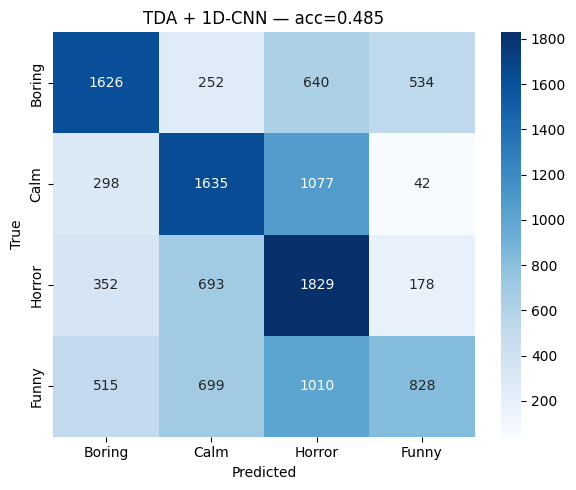

Saved -> tda_cnn_results.csv


In [14]:
# Load best weights before final evaluation
model.load_state_dict(best_weights)
print(f"\nLoaded best model (val_acc={best_val_acc:.4f})")
model.eval()
with torch.no_grad():
    y_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy : {acc:.4f}   (val_acc during training: {best_val_acc:.4f})\n")
print(classification_report(y_test, y_pred, target_names=EMOTION_LABELS))

plot_cm(y_test, y_pred, f"TDA + 1D-CNN — acc={acc:.3f}")

pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(
    "tda_cnn_results.csv", index=False
)
print("Saved -> tda_cnn_results.csv")


Single model (no TTA) test_acc: see cell above
Single model + TTA   test_acc: 0.4913
              precision    recall  f1-score   support

      Boring       0.59      0.54      0.57      3052
        Calm       0.52      0.53      0.52      3052
      Horror       0.40      0.61      0.48      3052
       Funny       0.54      0.28      0.37      3052

    accuracy                           0.49     12208
   macro avg       0.51      0.49      0.49     12208
weighted avg       0.51      0.49      0.49     12208



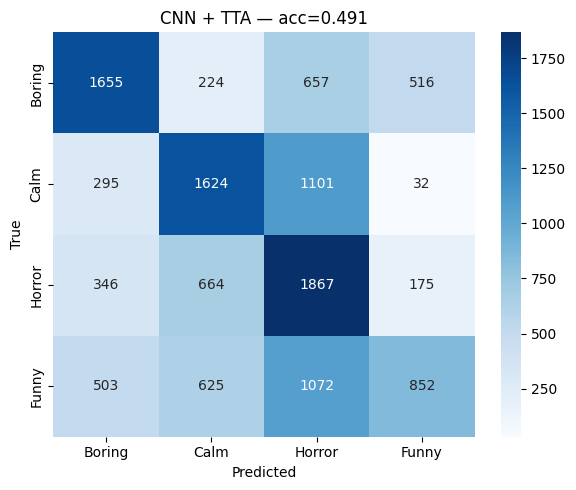

In [15]:
# ── Test-time augmentation (TTA) on the single best model ──────────
# Free accuracy, no retraining: instead of one forward pass per test
# sample, average predictions over several randomly channel-dropped
# views of the same sample. Smooths out over-reliance on any single
# electrode's feature values at inference time.
import torch.nn.functional as F

def tta_predict_proba(m, X_t, n_views=10, drop_p=0.1):
    m.eval()
    probs = None
    with torch.no_grad():
        for v in range(n_views):
            Xv = X_t.to(device)
            if v > 0:  # first view = clean, no dropout
                mask = (torch.rand(Xv.size(0), 1, Xv.size(2), device=device) > drop_p).float()
                Xv = Xv * mask
            p = F.softmax(m(Xv), dim=1).cpu().numpy()
            probs = p if probs is None else probs + p
    return probs / n_views

model.load_state_dict(best_weights)
tta_test_proba = tta_predict_proba(model, X_te_t, n_views=10, drop_p=0.1)
tta_test_pred  = tta_test_proba.argmax(1)
tta_test_acc   = accuracy_score(y_test, tta_test_pred)

print(f"Single model (no TTA) test_acc: {accuracy_score(y_test, model(X_te_t.to(device)).argmax(1).cpu().numpy()) if False else 'see cell above'}")
print(f"Single model + TTA   test_acc: {tta_test_acc:.4f}")
print(classification_report(y_test, tta_test_pred, target_names=EMOTION_LABELS))
plot_cm(y_test, tta_test_pred, f"CNN + TTA — acc={tta_test_acc:.3f}")



--- Seed model 1/2 (seed=13) ---
Seed 13 best val_acc: 0.5005

--- Seed model 2/2 (seed=42) ---
Seed 42 best val_acc: 0.5054

2-seed ensemble — val_acc: 0.5078   test_acc: 0.4952
              precision    recall  f1-score   support

      Boring       0.60      0.59      0.59      3052
        Calm       0.54      0.51      0.53      3052
      Horror       0.38      0.58      0.46      3052
       Funny       0.55      0.30      0.39      3052

    accuracy                           0.50     12208
   macro avg       0.52      0.50      0.49     12208
weighted avg       0.52      0.50      0.49     12208



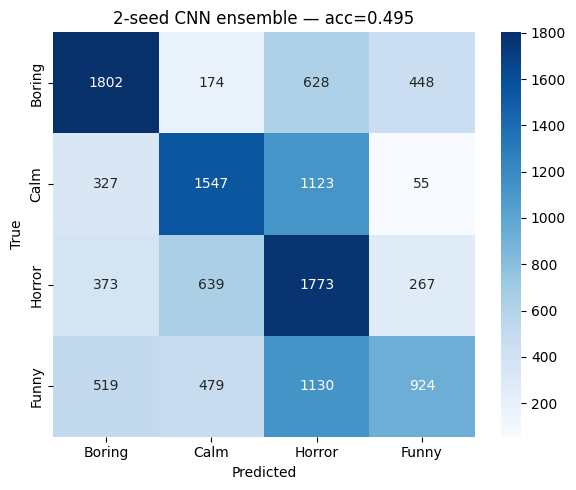

In [16]:
# ── Multi-seed ensemble ─────────────────────────────────────────────
# Train the SAME architecture N times with different random seeds,
# using the tuned config from the hyperparameter search, then average
# their softmax predictions. This is not a different model — it's
# still one architecture — but it cancels out the run-to-run noise
# you've been seeing (your val_acc has swung 0.44 -> 0.50 across runs
# just from different random init/batch order). Averaging several
# independent runs is one of the most reliable ways to squeeze extra
# points out of a small, noisy dataset without changing anything else.
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
import torch.nn.functional as F

N_SEEDS       = 2     # reduced from 3 -- this cell was taking very long; 2 seeds still
                       # cancels out most run-to-run noise for a fraction of the cost
SEED_EPOCHS   = 45    # reduced from 70 -- shorter per-seed budget, same reasoning
_cfg = dict(best_cfg) if "best_cfg" in dir() else {
    "mixup_alpha": 0.3, "chan_drop_p": 0.15, "weight_decay": 1e-3, "max_lr": 1.5e-3,
}
if _cfg["mixup_alpha"] < 0.2:
    _cfg["mixup_alpha"] = 0.2
if _cfg["chan_drop_p"] < 0.1:
    _cfg["chan_drop_p"] = 0.1

def train_one_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    m = TDA_CNN1D(feat_per_channel=FEAT_PER_CHANNEL, n_channels=N_CHANNELS).to(device)
    crit = FocalLoss(gamma=2.0, label_smoothing=0.05)
    opt = torch.optim.AdamW(m.parameters(), lr=_cfg["max_lr"], weight_decay=_cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=_cfg["max_lr"], epochs=SEED_EPOCHS, steps_per_epoch=len(train_loader),
        pct_start=0.25, div_factor=10, final_div_factor=100,
    )
    swa_start = int(SEED_EPOCHS * 0.7)
    swa_m = AveragedModel(m)
    swa_sched = SWALR(opt, swa_lr=2e-4)

    best_acc_seed, best_w_seed = 0.0, None
    for epoch in range(1, SEED_EPOCHS + 1):
        m.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            Xb = Xb + torch.randn_like(Xb) * 0.05
            if _cfg["chan_drop_p"] > 0:
                mask = (torch.rand(Xb.size(0), 1, Xb.size(2), device=device) > _cfg["chan_drop_p"]).float()
                Xb = Xb * mask
            if _cfg["mixup_alpha"] > 0:
                lam = float(np.random.beta(_cfg["mixup_alpha"], _cfg["mixup_alpha"]))
                idx = torch.randperm(Xb.size(0), device=device)
                Xm = lam * Xb + (1 - lam) * Xb[idx]
                ya, yb2 = yb, yb[idx]
            else:
                Xm, ya, yb2, lam = Xb, yb, yb, 1.0
            opt.zero_grad()
            out = m(Xm)
            loss = lam * crit(out, ya) + (1 - lam) * crit(out, yb2)
            loss.backward()
            opt.step()
            if epoch <= swa_start:
                sched.step()
        if epoch > swa_start:
            swa_m.update_parameters(m)
            swa_sched.step()

        m.eval()
        with torch.no_grad():
            val_pred = m(X_val_t.to(device)).argmax(1).cpu().numpy()
        acc = accuracy_score(y_val_split, val_pred)
        if acc > best_acc_seed:
            best_acc_seed = acc
            best_w_seed = {k: v.clone() for k, v in m.state_dict().items()}
        m.train()

    update_bn(train_loader, swa_m, device=device)
    swa_m.eval()
    with torch.no_grad():
        swa_acc = accuracy_score(y_val_split, swa_m(X_val_t.to(device)).argmax(1).cpu().numpy())
    if swa_acc >= best_acc_seed:
        m.load_state_dict(swa_m.module.state_dict())
        final_acc = swa_acc
    else:
        m.load_state_dict(best_w_seed)
        final_acc = best_acc_seed

    return m, final_acc


seed_models = []
for i, seed in enumerate([13, 42, 777, 2024, 99][:N_SEEDS], 1):
    print(f"\n--- Seed model {i}/{N_SEEDS} (seed={seed}) ---")
    m, acc = train_one_seed(seed)
    seed_models.append(m)
    print(f"Seed {seed} best val_acc: {acc:.4f}")

# Average softmax probabilities across all seed models
def ensemble_predict_proba(models, X_t):
    probs = None
    for m in models:
        m.eval()
        with torch.no_grad():
            p = F.softmax(m(X_t.to(device)), dim=1).cpu().numpy()
        probs = p if probs is None else probs + p
    return probs / len(models)

val_proba  = ensemble_predict_proba(seed_models, X_val_t)
test_proba = ensemble_predict_proba(seed_models, X_te_t)

ens_val_acc  = accuracy_score(y_val_split, val_proba.argmax(1))
ens_test_acc = accuracy_score(y_test, test_proba.argmax(1))
print(f"\n{N_SEEDS}-seed ensemble — val_acc: {ens_val_acc:.4f}   test_acc: {ens_test_acc:.4f}")
print(classification_report(y_test, test_proba.argmax(1), target_names=EMOTION_LABELS))
plot_cm(y_test, test_proba.argmax(1), f"{N_SEEDS}-seed CNN ensemble — acc={ens_test_acc:.3f}")


Random Forest — val_acc: 0.4085   test_acc: 0.4672
CNN (SWA)     — val_acc: 0.5108   test_acc: 0.4848

Best blend on val: alpha(RF)=0.15, alpha(CNN)=0.85 -> val_acc=0.5110

RF only        test_acc: 0.4672
CNN only       test_acc: 0.4848
RF+CNN blend   test_acc: 0.4879

              precision    recall  f1-score   support

      Boring       0.59      0.55      0.57      3052
        Calm       0.50      0.54      0.52      3052
      Horror       0.40      0.60      0.48      3052
       Funny       0.53      0.27      0.36      3052

    accuracy                           0.49     12208
   macro avg       0.50      0.49      0.48     12208
weighted avg       0.50      0.49      0.48     12208



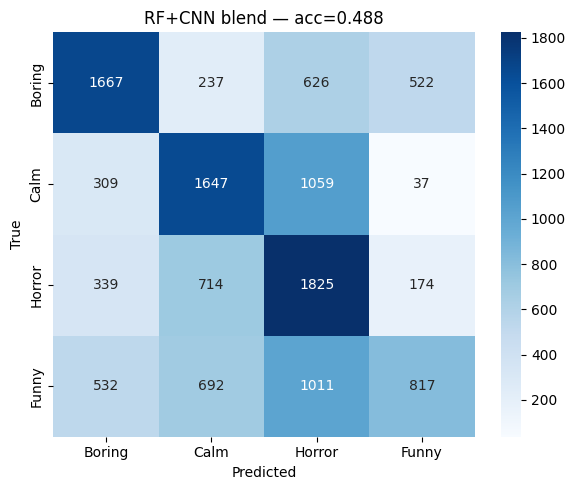

Saved -> rf_cnn_blend_results.csv


In [17]:
# ── Random Forest baseline + RF/CNN probability ensemble ──────────
# RF and the CNN make different kinds of errors on the same features
# (axis-aligned splits vs smooth learned nonlinear combinations + SE
# channel attention), so averaging their predicted probabilities
# usually beats either one alone. The blend weight alpha is picked on
# VAL only, then locked in and applied once to test — no test leakage.
from sklearn.ensemble import RandomForestClassifier
import torch.nn.functional as F

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)   # per-subject-normalized features, same ones the CNN used

rf_val_proba  = rf.predict_proba(X_valset)
rf_test_proba = rf.predict_proba(X_test)

rf_val_acc  = accuracy_score(y_val_split, rf_val_proba.argmax(1))
rf_test_acc = accuracy_score(y_test, rf_test_proba.argmax(1))
print(f"Random Forest — val_acc: {rf_val_acc:.4f}   test_acc: {rf_test_acc:.4f}")

# CNN softmax probabilities (best/SWA weights already loaded from the cell above)
model.eval()
with torch.no_grad():
    cnn_val_proba  = F.softmax(model(X_val_t.to(device)), dim=1).cpu().numpy()
    cnn_test_proba = F.softmax(model(X_te_t.to(device)), dim=1).cpu().numpy()

cnn_val_acc  = accuracy_score(y_val_split, cnn_val_proba.argmax(1))
cnn_test_acc = accuracy_score(y_test, cnn_test_proba.argmax(1))
print(f"CNN (SWA)     — val_acc: {cnn_val_acc:.4f}   test_acc: {cnn_test_acc:.4f}")

# Grid search the blend weight on VAL only
best_alpha, best_blend_val_acc = 0.5, 0.0
for alpha in np.arange(0.0, 1.01, 0.05):
    blend_val = alpha * rf_val_proba + (1 - alpha) * cnn_val_proba
    acc = accuracy_score(y_val_split, blend_val.argmax(1))
    if acc > best_blend_val_acc:
        best_blend_val_acc, best_alpha = acc, alpha

print(f"\nBest blend on val: alpha(RF)={best_alpha:.2f}, alpha(CNN)={1-best_alpha:.2f} -> val_acc={best_blend_val_acc:.4f}")

blend_test_proba = best_alpha * rf_test_proba + (1 - best_alpha) * cnn_test_proba
blend_test_pred  = blend_test_proba.argmax(1)
blend_test_acc   = accuracy_score(y_test, blend_test_pred)

print(f"\n{'='*50}")
print(f"RF only        test_acc: {rf_test_acc:.4f}")
print(f"CNN only       test_acc: {cnn_test_acc:.4f}")
print(f"RF+CNN blend   test_acc: {blend_test_acc:.4f}")
print(f"{'='*50}\n")

print(classification_report(y_test, blend_test_pred, target_names=EMOTION_LABELS))
plot_cm(y_test, blend_test_pred, f"RF+CNN blend — acc={blend_test_acc:.3f}")

pd.DataFrame({"y_true": y_test, "y_pred": blend_test_pred}).to_csv(
    "rf_cnn_blend_results.csv", index=False
)
print("Saved -> rf_cnn_blend_results.csv")
